# Data Cleaning and Exploratory Data Analysis on CAVA Restaurant Orders

## Introduction

CAVA is a fast-casual restaurant brand that offers customizable Mediterranean-inspired bowls, pitas, salads, and dips made with fresh, high-quality ingredients. Founded in 2010, the company combines traditional Mediterranean flavors with a modern, convenient dining experience that emphasizes healthy and flavorful meals. The brand has expanded rapidly across the United States by appealing to customers seeking fresh, quick, and customizable food options. 

The dataset is a simulated dataset that includes customer customization, nutritional, and sales information of individual customer orders. 

Our task is to clean and explore the data. 

## Preparing the Environment
We will import the required libraries and read in the data set.

Pandas and Numpy - Data manipulation  
Matplotlib and Seaborn - Data visualization

In [1]:
# Import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Read in CSV formatted dataset
cava_orders = pd.read_csv('/Users/sarina/Desktop/cava_orders.csv')

## Initial Data Information

Let's have a look at the data using df.info() and df.head() functions.

In [3]:
# Preview the column names, non-null cell counts, and data types of each variable
cava_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           45 non-null     int64  
 1   customer_id        45 non-null     object 
 2   order_date         45 non-null     object 
 3   order_time         45 non-null     object 
 4   Location           45 non-null     object 
 5   base_item          45 non-null     object 
 6   Protein            45 non-null     object 
 7   dip_1              45 non-null     object 
 8   dip_2              28 non-null     object 
 9   Topping_1          45 non-null     object 
 10  topping_2          45 non-null     object 
 11  topping_3          21 non-null     object 
 12  Dressing           45 non-null     object 
 13  meal_format        45 non-null     object 
 14  calories           44 non-null     float64
 15  Protein_g          45 non-null     int64  
 16  carbs_g            45 non-nu

In [4]:
# Preview the first 5 rows of the dataset
cava_orders.head()

,order_id,customer_id,order_date,order_time,Location,base_item,Protein,dip_1,dip_2,Topping_1,...,calories,Protein_g,carbs_g,fat_g,Fiber_g,Sodium_mg,price,rating,delivery_platform,order_type
0,1001,C001,2024-01-08,12:34,DC - Logan Circle,Saffron Basmati Rice,Grilled Chicken,Hummus,Tzatziki,Tomato + Cucumber,...,620.0,47,71,15,4,1810,14.50,5.0,none,dine-in
1,1002,C002,2024-01-08,13:05,DC - Logan Circle,supergreens,Falafel,Hummus,Crazy Feta,Cabbage Slaw,...,710.0,18,55,48,16,1430,15.25,4.0,NaN,dine-in
2,1003,C003,2024-01-09,11:50,MD - Bethesda,Brown Rice,Braised Lamb,Red Pepper Hummus,NaN,Persian Cucumber,...,810.0,38,62,38,9,1980,16.00,5.0,none,dine-in
3,1004,C004,2024-01-09,18:22,VA - Arlington,Saffron Basmati Rice,Harissa Honey Chicken,Harissa,Tzatziki,Corn,...,850.0,36,82,32,5,1940,14.75,NaN,uber eats,delivery
4,1005,C005,2024-01-10,12:15,DC - Capitol Hill,Pita,Grilled Chicken,Hummus,NaN,Tomato + Cucumber,...,870.0,48,69,45,12,2560,13.50,4.0,none,dine-in


The dataset has 45 customer orders and 24 columns including a mix of categorical, time, and numerical variables.

Each row represents an individual customer order and the corresponding contents, nutrition, and price information. There is also information on the order's store location and order type.

Before moving on to cleaning the data, let's see if there are any Null values. We are only expecting to have Null values for ingredient variables where customers have the ability to choose multiple options (dips and toppings within this dataset). 

In [5]:
cava_orders.isnull().sum()[cava_orders.isnull().sum() > 0]

dip_2                17
topping_3            24
calories              1
rating                3
delivery_platform     1
dtype: int64

There are Null values in 5 columns. The only columns expected to have Null values were the dip_2 and topping_3 columns. We will handle the missing values in the calories, rating, and delivery_platform columns in the next section. 

## Data Cleaning

Before we can properly explore the data, we need to clean it.

For this analysis, we will look at the more common issues such as missing data, duplicated data, and inconsistent naming.

### Handling Inconsistent Naming

From looking at cava_orders.info(), we can see that there are inconsistencies with column naming and categorical variable option naming. The inconsistencies include differences in casing and spacing.

Let's start with the inconsistent column naming. 

In [6]:
# List the initial column names
print("\nInitial Column names:")
print(cava_orders.columns.tolist())


Initial Column names:
['order_id', 'customer_id', 'order_date', 'order_time', 'Location', 'base_item', 'Protein', 'dip_1', 'dip_2', 'Topping_1', 'topping_2', 'topping_3', 'Dressing', 'meal_format', 'calories', 'Protein_g', 'carbs_g', 'fat_g', 'Fiber_g', 'Sodium_mg', 'price', 'rating', 'delivery_platform', 'order_type']


In [7]:
# Update and list new column names
cava_orders.columns = (
    cava_orders.columns
      .str.strip()
      .str.lower()
)
print("\nUpdated column names:")
print(cava_orders.columns.tolist())


Updated column names:
['order_id', 'customer_id', 'order_date', 'order_time', 'location', 'base_item', 'protein', 'dip_1', 'dip_2', 'topping_1', 'topping_2', 'topping_3', 'dressing', 'meal_format', 'calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sodium_mg', 'price', 'rating', 'delivery_platform', 'order_type']


The updated column names make the names more readable and eliminates the question of "Was this variable capitalized?"

Let's move on to cleaning our categorical variables. 

First up is base_item. Let's look at the original values we're working with. 

In [8]:
# Initial base_item values
print(f"\nOriginal base_item values:")
print(cava_orders["base_item"].value_counts())


Original base_item values:
Black Lentils           8
Saffron Basmati Rice    7
Brown Rice              7
Pita                    6
Supergreens             5
saffron basmati rice    4
supergreens             2
pita                    2
SUPERGREENS             1
Brown rice              1
BROWN RICE              1
SuperGreens             1
Name: base_item, dtype: int64


We definitely have multiple names for the same base items. SuperGreens has 4 different values, Saffron Basmati Rice has 2 values, Brown Rice has 3 values, and Pita has 2 values. 

Let's combine these values so we have 1 for each base item. 

In [9]:
# Map out desired base_item categories and update values
base_item_map = {
    "supergreens": "SuperGreens",
    "super greens": "SuperGreens",
    "saffron basmati rice": "Saffron Basmati Rice",
    "brown rice": "Brown Rice",
    "black lentils": "Black Lentils",
    "pita": "Pita",
}
cava_orders["base_item"] = cava_orders["base_item"].str.strip().str.lower().map(
    lambda x: base_item_map.get(x, x.title())
)
print(f"\nUpdated base_item values:")
print(cava_orders["base_item"].value_counts())


Updated base_item values:
Saffron Basmati Rice    11
SuperGreens              9
Brown Rice               9
Pita                     8
Black Lentils            8
Name: base_item, dtype: int64


Much better. We can now see that we have 5 base_item options with 8-11 orders each. 

Let's look at the the protein options now. 

In [10]:
# Initial protein values
print(f"\nOriginal protein values:")
print(cava_orders["protein"].value_counts())


Original protein values:
Grilled Chicken          10
Braised Lamb              8
Falafel                   6
Harissa Honey Chicken     6
Grilled Steak             3
Spicy Lamb                2
grilled chicken           2
GRILLED CHICKEN           2
grilled steak             2
FALAFEL                   1
falafel                   1
GRILLED STEAK             1
harissa honey chicken     1
Name: protein, dtype: int64


Our protein values have the same casing issue as our base_item values, but they don't have the spacing issues.

Let's combine the protein values so there's one value for each protein option.

In [11]:
# Update protein values
cava_orders["protein"] = cava_orders["protein"].str.strip().str.title()
print(f"\nUpdated protein values:")
print(cava_orders["protein"].value_counts())


Updated protein values:
Grilled Chicken          14
Falafel                   8
Braised Lamb              8
Harissa Honey Chicken     7
Grilled Steak             6
Spicy Lamb                2
Name: protein, dtype: int64


Now we have 6 protein values with 2-14 orders each. 

Next to check is the meal_format values. We should have 2: Bowl and Pita. 

In [12]:
# Original meal_format values
print(f"\nOriginal meal_format values: {cava_orders['meal_format'].value_counts().to_dict()}")


Original meal_format values: {'Bowl': 37, 'Pita': 8}


Looks like the meal_format variable is consistent. 

Let's wrap up the rest of the categorical ingredient variables. 

In [13]:
# Original dip, dressing, and topping variables
cava_orders[["dip_1", "dip_2", "dressing", "topping_1", "topping_2", "topping_3"]].head(10)

,dip_1,dip_2,dressing,topping_1,topping_2,topping_3
0,Hummus,Tzatziki,Lemon Herb Tahini,Tomato + Cucumber,Pickled Onions,NaN
1,Hummus,Crazy Feta,Lemon Herb Tahini,Cabbage Slaw,Pickled Onions,Avocado
2,Red Pepper Hummus,NaN,Greek Vinaigrette,Persian Cucumber,Tomato + Cucumber,Feta
3,Harissa,Tzatziki,Garlic Dressing,Corn,Pickled Onions,Broccoli
4,Hummus,NaN,Lemon Herb Tahini,Tomato + Cucumber,Cabbage Slaw,NaN
5,Crazy Feta,Harissa,Skhug,Pickled Onions,Avocado,NaN
6,Hummus,Crazy Feta,Lemon Herb Tahini,Cabbage Slaw,Pickled Onions,Avocado
7,Harissa,Red Pepper Hummus,Garlic Dressing,Tomato + Cucumber,Corn,Feta
8,Tzatziki,NaN,Lemon Herb Tahini,Persian Cucumber,Pickled Onions,NaN
9,Hummus,Crazy Feta,Green Goddess Ranch,Cabbage Slaw,Pickled Onions,Avocado


In [14]:
# Update dip, dressing, and topping variables
for col in ["dip_1", "dip_2", "dressing", "topping_1", "topping_2", "topping_3"]:
    cava_orders[col] = cava_orders[col].str.strip().str.title()
    
cava_orders[["dip_1", "dip_2", "dressing", "topping_1", "topping_2", "topping_3"]].head(10)

,dip_1,dip_2,dressing,topping_1,topping_2,topping_3
0,Hummus,Tzatziki,Lemon Herb Tahini,Tomato + Cucumber,Pickled Onions,NaN
1,Hummus,Crazy Feta,Lemon Herb Tahini,Cabbage Slaw,Pickled Onions,Avocado
2,Red Pepper Hummus,NaN,Greek Vinaigrette,Persian Cucumber,Tomato + Cucumber,Feta
3,Harissa,Tzatziki,Garlic Dressing,Corn,Pickled Onions,Broccoli
4,Hummus,NaN,Lemon Herb Tahini,Tomato + Cucumber,Cabbage Slaw,NaN
5,Crazy Feta,Harissa,Skhug,Pickled Onions,Avocado,NaN
6,Hummus,Crazy Feta,Lemon Herb Tahini,Cabbage Slaw,Pickled Onions,Avocado
7,Harissa,Red Pepper Hummus,Garlic Dressing,Tomato + Cucumber,Corn,Feta
8,Tzatziki,NaN,Lemon Herb Tahini,Persian Cucumber,Pickled Onions,NaN
9,Hummus,Crazy Feta,Green Goddess Ranch,Cabbage Slaw,Pickled Onions,Avocado


Now that the categorical ingredient variables are cleaned up we can move on to the next cleaning sequence. 

### Handling Missing Data

As a refresher from the Initial Data Information section, we have 3 variables with unexpected missing values. These variables are calories, rating, and delivery_platform. 

We'll handle delivery_platform first. 

In [15]:
# Initial delivery_platform options
print(f"\nOriginal delivery_platform values: {cava_orders['delivery_platform'].value_counts().to_dict()}")


Original delivery_platform values: {'none': 34, 'uber eats': 6, 'doordash': 4}


We have 3 value options: none, uber eats, and doordash. We want to change the none option and any null values to In-Store. We also want to update the delivery service options to match the company's name casing. 

In [16]:
# Update delivery_platform options
cava_orders["delivery_platform"] = (
    cava_orders["delivery_platform"]
      .str.strip()
      .str.lower()
      .replace({"none": "In-Store", "": "In-Store"})
      .fillna("In-Store")
)
platform_clean = {
    "uber eats": "Uber Eats",
    "doordash": "DoorDash",
    "in-store": "In-Store",
}
cava_orders["delivery_platform"] = cava_orders["delivery_platform"].map(
    lambda x: platform_clean.get(x.lower()))
print(f"\nUpdated delivery_platform values: {cava_orders['delivery_platform'].value_counts().to_dict()}")


Updated delivery_platform values: {'In-Store': 35, 'Uber Eats': 6, 'DoorDash': 4}


Now we have our 3 value options: In-Store, Uber Eats, and DoorDash. There was also 1 null value in the delivery_platform column which has now been updated to In-Store. 

We'll look at rating and calories next. For both the missing rating and calories information, we will use median values to approxiamte the information. Calories will use the median calories grouped by base_item and rating will use the median rating. 

First, let's check and make sure there aren't any outlier values in our missing values columns. For calories, let's assume all orders should be between 100 and 2000 calories. All ratings should be between 1 and 5. 

In [17]:
# Check outliers in columns with missing informtion
missing_cols = ["calories", "rating"]

for col in missing_cols:
    cava_orders[col] = pd.to_numeric(cava_orders[col], errors="coerce")

valid_ranges = {
    "calories": (100, 2000),
    "rating": (1, 5),
}

# Print outlier values and convert to Null
for col, (low, high) in valid_ranges.items():
    to_null = (cava_orders[col] < low) | (cava_orders[col] > high)
    if to_null.any():
        print(f"\n'{col}': {to_null.sum()} outliers" f"({cava_orders.loc[to_null, col].tolist()})")
        cava_orders.loc[to_null, col] = np.nan

print(f"\nMissing values after outlier check:")
print(cava_orders[missing_cols].isnull().sum()[cava_orders[missing_cols].isnull().sum() > 0])


'calories': 2 outliers([9999.0, -50.0])

Missing values after outlier check:
calories    3
rating      3
dtype: int64


So, we had 2 calories outliers with values 9999 and -50. Now we have 3 calories values to fill and 3 rating values to fill. 

Let's calculate the medians for calories by base_item group and rating.

In [18]:
# Calculate calorie median values
calorie_medians = cava_orders.groupby('base_item')['calories'].median()
calorie_medians

base_item
Black Lentils           680.0
Brown Rice              820.0
Pita                    940.0
Saffron Basmati Rice    770.0
SuperGreens             600.0
Name: calories, dtype: float64

In [19]:
# Calculate ratings median value
rating_median = cava_orders['rating'].median()
rating_median

4.0

Now that we have our fill values, we'll update our Null values for calories and rating. 

In [20]:
# Update missing values and check for remaining Null values
cava_orders["calories"] = cava_orders["calories"].fillna(cava_orders.groupby('base_item')['calories'].median())
cava_orders["rating"] = cava_orders["rating"].fillna(cava_orders["rating"].median())

print(f"\nMissing after data substitution:")
print(cava_orders[missing_cols].isnull().sum()[cava_orders[missing_cols].isnull().sum() > 0])


Missing after data substitution:
calories    3
dtype: int64


Great! No more missing data. We are almost done with cleaning this dataset. 

### Duplicated Data

The last data cleaning step for this analysis is to double check there are no duplicated orders.

In [21]:
# Check for duplicated orders
before = len(cava_orders)
cava_orders.drop_duplicates(inplace=True)
print(f"\nDropped {before - len(cava_orders)} duplicate row(s). Rows now: {len(cava_orders)}")


Dropped 0 duplicate row(s). Rows now: 45


There are no duplicated orders in this dataset. 

Let's wrap up data cleaning by taking a look at the cleaned dataset and confirming the only Null values remaining are in the dip_2 and topping_3 columns.

In [22]:
# # Preview the first 5 rows of the cleaned dataset
cava_orders.head()

,order_id,customer_id,order_date,order_time,location,base_item,protein,dip_1,dip_2,topping_1,...,calories,protein_g,carbs_g,fat_g,fiber_g,sodium_mg,price,rating,delivery_platform,order_type
0,1001,C001,2024-01-08,12:34,DC - Logan Circle,Saffron Basmati Rice,Grilled Chicken,Hummus,Tzatziki,Tomato + Cucumber,...,620.0,47,71,15,4,1810,14.50,5.0,In-Store,dine-in
1,1002,C002,2024-01-08,13:05,DC - Logan Circle,SuperGreens,Falafel,Hummus,Crazy Feta,Cabbage Slaw,...,710.0,18,55,48,16,1430,15.25,4.0,In-Store,dine-in
2,1003,C003,2024-01-09,11:50,MD - Bethesda,Brown Rice,Braised Lamb,Red Pepper Hummus,NaN,Persian Cucumber,...,810.0,38,62,38,9,1980,16.00,5.0,In-Store,dine-in
3,1004,C004,2024-01-09,18:22,VA - Arlington,Saffron Basmati Rice,Harissa Honey Chicken,Harissa,Tzatziki,Corn,...,850.0,36,82,32,5,1940,14.75,4.0,Uber Eats,delivery
4,1005,C005,2024-01-10,12:15,DC - Capitol Hill,Pita,Grilled Chicken,Hummus,NaN,Tomato + Cucumber,...,870.0,48,69,45,12,2560,13.50,4.0,In-Store,dine-in


In [23]:
# Check Null value columns
cava_orders.isnull().sum()[cava_orders.isnull().sum() > 0]

dip_2        17
topping_3    24
calories      3
dtype: int64

The dataset now looks like we expect it to. We have updated inconsistent naming, handled unexpected missing values, and made sure there are not duplicated orders. Now, we can move on to some further exploration of the dataset. 

## Descriptive Statistics

In this section, we will do some descriptive statistical analysis. To start, let's look at a descriptive statistics summary of some of our numeric variables. 

In [24]:
# Get descriptive statistics summary for numeric variables
print(cava_orders[["calories", "protein_g", "carbs_g", "fat_g", "fiber_g", "sodium_mg", "price", "rating"]].describe().round(2))

       calories  protein_g  carbs_g  fat_g  fiber_g  sodium_mg  price  rating
count     42.00      45.00    45.00  45.00    45.00      45.00  45.00   45.00
mean     751.67      37.29    62.69  35.42    10.36    1846.67  14.96    4.13
std      140.14       9.76    17.25  12.68     4.63     340.94   0.73    0.94
min      490.00      16.00    18.00  14.00     4.00    1280.00  13.50    1.00
25%      625.00      35.00    55.00  26.00     7.00    1590.00  14.50    4.00
50%      770.00      38.00    68.00  38.00     9.00    1810.00  14.75    4.00
75%      867.50      44.00    74.00  45.00    15.00    2020.00  15.50    5.00
max      980.00      48.00    88.00  56.00    18.00    2560.00  16.50    5.00


For our numeric variables, it's interesting to note that
* Across all locations, the mean and median ratings are 4.13 and 4, respectively. At least 75% of ratings were 4 or above. 
* All of the macros (protein, carbs, and fat) spread across a wide range, 32g-70g, with carbs having the widest range of 70g and protein having the smallest range at 32g. 
* Calories also covers a wide range of almost 500 calories. 

We will perform some additional analysis on these findings below. 

Let's take a look at the average calories by base item and meal format. 

In [25]:
print(cava_orders.groupby(["base_item", "meal_format"])["calories"].mean().round(1).unstack())

meal_format            Bowl   Pita
base_item                         
Black Lentils         672.9    NaN
Brown Rice            816.7    NaN
Pita                    NaN  915.7
Saffron Basmati Rice  764.0    NaN
SuperGreens           606.7    NaN


It looks like Pita has the highest calories on average and SuperGreens has the lowest calories on average based on these customer orders. 

Let's move on to ratings. How do ratings compare by store location?

In [26]:
print(cava_orders.groupby("location")["rating"].mean().round(2).sort_values(ascending=False))

location
DC - Logan Circle    4.57
MD - Bethesda        4.36
VA - Arlington       3.90
DC - Capitol Hill    3.50
Name: rating, dtype: float64


DC has the highest and lowest ratings for this set of customer orders. The Logan Circle location has the highest rating of 4.57/5 and the Capital Hill location has the lowest at 3.50/5. 

Now that we've explored the data a bit, let's make some visuals of the data. 

## Exploratory Data Analysis

We will look at the nutrition patterns for this set of customer orders. 

### 1. Which base item yields an order with the most and least calories? 

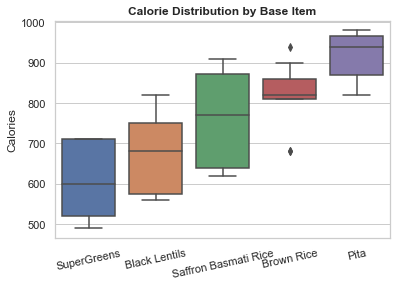

In [27]:
sns.set_theme(style="whitegrid")

order = cava_orders.groupby("base_item")["calories"].median().sort_values().index
sns.boxplot(data=cava_orders, x="base_item", y="calories", order=order)

plt.title("Calorie Distribution by Base Item", fontweight="bold")
plt.xlabel("")
plt.ylabel("Calories")
plt.tick_params(axis="x", rotation=12)

From the boxplot, we can deduce that 
* If a customer wants a low calorie meal order, they should order SuperGreens as their base item. 
* If a customer wants a high calorie meal order, they should order Pita as their base item. 

### 2. What are the average macros by base item? 

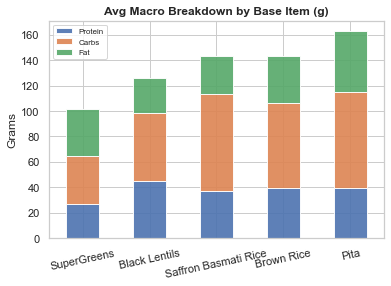

In [28]:
sns.set_theme(style="whitegrid")

macro_cols = ["protein_g", "carbs_g", "fat_g"]
macro_means = cava_orders.groupby("base_item")[macro_cols].mean().loc[order]

macro_means.plot(kind="bar", stacked=True, alpha=0.9)

plt.title("Avg Macro Breakdown by Base Item (g)", fontweight="bold")
plt.xlabel("")
plt.ylabel("Grams")
plt.tick_params(axis="x", rotation=12)
plt.legend(["Protein", "Carbs", "Fat"], loc="upper left", fontsize=8)

From the stacked bar plot, we can see that 
* Base items Saffron Basmati Rice and Pita have the highest amount of carbs on average. Pita has the lowest amount of carbs on average.
* SuperGreens has the lowest amount of protein on average. Black Lentils has the highest amount of protein on average.
* Pita has the highest amount of fat on average. Black lentils have the lowest amount of fat on average. 

In [29]:
cava_orders.to_csv("cava_orders_clean.csv", index=False)